# Assignment 3: Build Non-Linear Models Part 1

**Todd DeLozier**

This notebook includes my responses for:

- Conceptual Question #1 (ISLR Python, p. 283)
- Applied Question #8 (ISLR Python, p. 286)

All code needed to reproduce the results is included below.


In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV

print("All imports successful")


All imports successful


# Part 1: Conceptual Question #1

**Prompt (from ISLR Python, p. 283):**

We perform best subset, forward stepwise, and backward stepwise selection on a single data set.
For each approach, we obtain $p+1$ models, containing $0,1,2,\ldots,p$ predictors. Explain your answers:

(a) Which of the three models with $k$ predictors has the smallest training RSS?

(b) Which of the three models with $k$ predictors has the smallest test RSS?

(c) True or False:

i. The predictors in the $k$-variable model identified by forward stepwise are a subset of the predictors in the $(k+1)$-variable model identified by forward stepwise selection.  
ii. The predictors in the $k$-variable model identified by backward stepwise are a subset of the predictors in the $(k+1)$-variable model identified by backward stepwise selection.  
iii. The predictors in the $k$-variable model identified by backward stepwise are a subset of the predictors in the $(k+1)$-variable model identified by forward stepwise selection.  
iv. The predictors in the $k$-variable model identified by forward stepwise are a subset of the predictors in the $(k+1)$-variable model identified by backward stepwise selection.  
v. The predictors in the $k$-variable model identified by best subset are a subset of the predictors in the $(k+1)$-variable model identified by best subset selection.


## Answer

### (a) Smallest training RSS (for a fixed $k$)

**Best subset selection** has the smallest training RSS among the three, for any fixed $k$.

Reason: best subset explicitly considers (in principle) all $\binom{p}{k}$ models with $k$ predictors and selects the one minimizing training RSS. Forward and backward stepwise search only along restricted paths, so their best $k$-predictor model may not be the global minimum-RSS choice.

### (b) Smallest test RSS (for a fixed $k$)

**No method is guaranteed** to have the smallest test RSS for a given $k$.

Reason: test RSS depends on generalization. Best subset tends to minimize training error but can overfit. Forward/backward may sometimes generalize better despite having higher training RSS.

### (c) True/False

i. **True**. Forward stepwise only adds predictors, so the $k$-variable model is nested within the $(k+1)$-variable model.  
ii. **True**. Backward stepwise removes predictors one at a time from the full model, so the $k$-variable model is nested within the $(k+1)$-variable model.  
iii. **False**. There is no guaranteed nesting relationship between backward and forward stepwise models.  
iv. **False**. There is no guaranteed nesting relationship between forward and backward stepwise models.  
v. **False**. Best subset models are not constrained to be nested; the best $(k+1)$-variable model can exclude predictors that were in the best $k$-variable model.


# Part 2: Applied Question #8

**Prompt (from ISLR Python, p. 286):**

In this exercise, I generate simulated data and then use it to perform forward and backward stepwise selection.

**(a)** Create a random number generator and use its `normal()` method to generate a predictor $X$ of length $n=100$, as well as a noise vector $\epsilon$ of length $n=100$.

**(b)** Generate a response vector $Y$ of length $n=100$ according to:

$$Y = \beta_0 + \beta_1 X + \beta_2 X^2 + \beta_3 X^3 + \epsilon,$$

where $\beta_0, \beta_1, \beta_2,$ and $\beta_3$ are constants of my choice.

**(c)** Use forward stepwise selection to select a model containing the predictors $X, X^2, \ldots, X^{10}$. What is the model obtained according to $C_p$? Report the coefficients of the selected model.

**(d)** Repeat (c) using backward stepwise selection. Compare the selected model to the result in (c).

**(e)** Fit a lasso model to the simulated data using $X, X^2, \ldots, X^{10}$ as predictors. Use cross-validation to select the optimal value of $\alpha$. Create a plot of cross-validation error as a function of $\alpha$. Report the resulting coefficient estimates and discuss the results.

**(f)** Generate a response vector $Y$ according to:

$$Y = \beta_0 + \beta_7 X^7 + \epsilon,$$

and perform forward stepwise selection and the lasso. Discuss the results.


In [2]:
# Reproducibility
np.random.seed(1)

# (a) Generate X and epsilon
n = 100
X = np.random.normal(size=n)
eps = np.random.normal(size=n)

# (b) Generate Y from a cubic polynomial + noise
b0, b1, b2, b3 = 3.0, 2.0, -1.5, 0.7
Y = b0 + b1*X + b2*(X**2) + b3*(X**3) + eps

# Build polynomial features X..X^10
Xpoly = pd.DataFrame({f"X{j}": X**j for j in range(1, 11)})
Xpoly.head()


,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10
0,1.624345,2.638498,4.285832,6.961671,11.308158,18.368354,29.836551,48.464863,78.723675,127.874436
1,-0.611756,0.374246,-0.228947,0.140060,-0.085683,0.052417,-0.032066,0.019617,-0.012001,0.007342
2,-0.528172,0.278965,-0.147342,0.077822,-0.041103,0.021710,-0.011466,0.006056,-0.003199,0.001689
3,-1.072969,1.151262,-1.235268,1.325403,-1.422116,1.525886,-1.637228,1.756694,-1.884878,2.022415
4,0.865408,0.748930,0.648130,0.560897,0.485404,0.420073,0.363534,0.314605,0.272262,0.235617


In [3]:
def fit_ols_cp(y, X_df, sigma2_hat):
    """Fit OLS with intercept and compute RSS and Mallows' Cp.

    Cp = RSS / sigma^2 - (n - 2p)
    where p is number of parameters INCLUDING the intercept.
    """
    n = len(y)
    X_design = sm.add_constant(X_df, has_constant="add")
    model = sm.OLS(y, X_design).fit()
    rss = float(np.sum(model.resid**2))
    p = X_design.shape[1]
    cp = rss / sigma2_hat - (n - 2*p)
    return model, rss, cp

def forward_stepwise_cp(y, X_all, sigma2_hat):
    remaining = list(X_all.columns)
    selected = []
    path = []

    while remaining:
        candidates = []
        for var in remaining:
            trial = selected + [var]
            model, rss, cp = fit_ols_cp(y, X_all[trial], sigma2_hat)
            candidates.append((cp, var, model, rss))
        candidates.sort(key=lambda t: t[0])
        best_cp, best_var, best_model, best_rss = candidates[0]
        selected.append(best_var)
        remaining.remove(best_var)
        path.append({"k": len(selected), "vars": selected.copy(), "cp": best_cp, "rss": best_rss, "model": best_model})

    best = min(path, key=lambda d: d["cp"])
    return best, path

def backward_stepwise_cp(y, X_all, sigma2_hat):
    selected = list(X_all.columns)
    path = []

    while True:
        model, rss, cp = fit_ols_cp(y, X_all[selected], sigma2_hat)
        path.append({"k": len(selected), "vars": selected.copy(), "cp": cp, "rss": rss, "model": model})

        if len(selected) == 1:
            break

        # choose which variable to drop based on minimal Cp after dropping
        candidates = []
        for var in selected:
            trial = [v for v in selected if v != var]
            m, r, c = fit_ols_cp(y, X_all[trial], sigma2_hat)
            candidates.append((c, var))
        candidates.sort(key=lambda t: t[0])
        _, drop_var = candidates[0]
        selected.remove(drop_var)

    best = min(path, key=lambda d: d["cp"])
    return best, path


In [4]:
# Estimate sigma^2 from the full model (all 10 predictors), then run stepwise procedures

full_model = sm.OLS(Y, sm.add_constant(Xpoly)).fit()
sigma2_hat = float(full_model.mse_resid)

print(f"sigma^2_hat (from full 10-predictor model): {sigma2_hat:.6f}")

# (c) Forward stepwise selection using Cp
best_fwd, fwd_path = forward_stepwise_cp(Y, Xpoly, sigma2_hat)
print("\nForward stepwise best model (min Cp):")
print("k =", best_fwd["k"])
print("vars =", best_fwd["vars"])
print("Cp =", best_fwd["cp"])

print("\nCoefficients (forward/Cp model):")
print(best_fwd["model"].params)

# (d) Backward stepwise selection using Cp
best_bwd, bwd_path = backward_stepwise_cp(Y, Xpoly, sigma2_hat)
print("\nBackward stepwise best model (min Cp):")
print("k =", best_bwd["k"])
print("vars =", best_bwd["vars"])
print("Cp =", best_bwd["cp"])

print("\nCoefficients (backward/Cp model):")
print(best_bwd["model"].params)


sigma^2_hat (from full 10-predictor model): 0.859529

Forward stepwise best model (min Cp):
k = 4
vars = ['X3', 'X2', 'X1', 'X6']
Cp = 2.841778098784758

Coefficients (forward/Cp model):
const    3.276949
X3       0.805378
X2      -1.842533
X1       1.910076
X6       0.020949
dtype: float64

Backward stepwise best model (min Cp):
k = 6
vars = ['X1', 'X4', 'X5', 'X6', 'X7', 'X8']
Cp = 6.781844117096028

Coefficients (backward/Cp model):
const    3.057617
X1       2.251371
X4      -2.285019
X5       0.457825
X6       0.852609
X7      -0.065809
X8      -0.090523
dtype: float64


Chosen alpha (LassoCV): 0.0066816235074669

Non-zero coefficients:
X3    2.017395
X2   -1.990194
X1    1.694009
X6    0.411574
X9    0.017107
dtype: float64


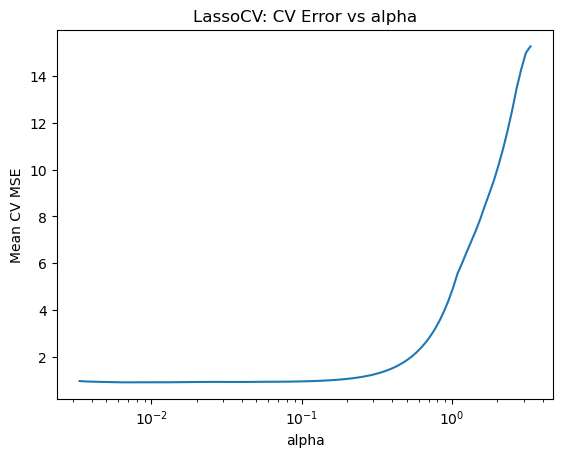

In [5]:
# (e) Lasso with cross-validation on X..X^10 features

lasso_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso", LassoCV(cv=10, random_state=1, max_iter=20000))
])

lasso_pipe.fit(Xpoly.values, Y)
lasso = lasso_pipe.named_steps["lasso"]

print("Chosen alpha (LassoCV):", lasso.alpha_)

coef = pd.Series(lasso.coef_, index=Xpoly.columns)
nonzero = coef[coef.abs() > 1e-8].sort_values(key=np.abs, ascending=False)

print("\nNon-zero coefficients:")
print(nonzero)

# Plot mean CV MSE vs alpha (log scale)
mse_mean = lasso.mse_path_.mean(axis=1)
alphas = lasso.alphas_

plt.figure()
plt.plot(alphas, mse_mean)
plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("Mean CV MSE")
plt.title("LassoCV: CV Error vs alpha")
plt.show()


sigma^2_hat2 (from full 10-predictor model): 0.859529

Forward stepwise best model (min Cp) for X^7 truth:
k = 3
vars = ['X7', 'X10', 'X2']
const    2.229363
X7       5.004278
X10      0.000642
X2      -0.191076
dtype: float64

Backward stepwise best model (min Cp) for X^7 truth:
k = 3
vars = ['X4', 'X6', 'X7']
const    2.194364
X4      -0.177049
X6       0.044484
X7       5.004169
dtype: float64

Chosen alpha (LassoCV) for X^7 truth: 0.25369427109449866

Non-zero coefficients (X^7 truth):
X7    226.136789
X9     15.620576
X5     11.919214
dtype: float64


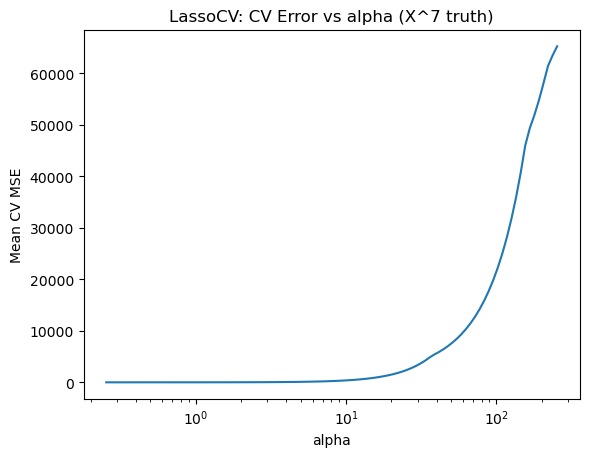

In [6]:
# (f) New response: Y = b0 + b7 * X^7 + epsilon; repeat forward stepwise and lasso

b0_f, b7 = 2.0, 5.0
Y2 = b0_f + b7*(X**7) + eps

full_model_2 = sm.OLS(Y2, sm.add_constant(Xpoly)).fit()
sigma2_hat2 = float(full_model_2.mse_resid)

print(f"sigma^2_hat2 (from full 10-predictor model): {sigma2_hat2:.6f}")

best_fwd2, _ = forward_stepwise_cp(Y2, Xpoly, sigma2_hat2)
best_bwd2, _ = backward_stepwise_cp(Y2, Xpoly, sigma2_hat2)

print("\nForward stepwise best model (min Cp) for X^7 truth:")
print("k =", best_fwd2["k"])
print("vars =", best_fwd2["vars"])
print(best_fwd2["model"].params)

print("\nBackward stepwise best model (min Cp) for X^7 truth:")
print("k =", best_bwd2["k"])
print("vars =", best_bwd2["vars"])
print(best_bwd2["model"].params)

lasso_pipe2 = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso", LassoCV(cv=10, random_state=1, max_iter=20000))
])
lasso_pipe2.fit(Xpoly.values, Y2)
lasso2 = lasso_pipe2.named_steps["lasso"]

print("\nChosen alpha (LassoCV) for X^7 truth:", lasso2.alpha_)
coef2 = pd.Series(lasso2.coef_, index=Xpoly.columns)
nonzero2 = coef2[coef2.abs() > 1e-8].sort_values(key=np.abs, ascending=False)

print("\nNon-zero coefficients (X^7 truth):")
print(nonzero2)

mse_mean2 = lasso2.mse_path_.mean(axis=1)
alphas2 = lasso2.alphas_

plt.figure()
plt.plot(alphas2, mse_mean2)
plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("Mean CV MSE")
plt.title("LassoCV: CV Error vs alpha (X^7 truth)")
plt.show()


## Interpretation summary

For parts (c) and (d), I compare the predictors selected by forward stepwise and backward stepwise selection under Mallows’ $C_p$. Because the data are generated from a cubic signal, I expect the procedures to favor terms aligned with $X$, $X^2$, and $X^3$, though higher-order terms can occasionally appear due to noise and correlation among polynomial features.

For part (e), I fit a lasso model using cross-validation to choose $\alpha$. The cross-validation curve shows how predictive error changes as the penalty increases. I report the resulting coefficient estimates and interpret any sparsity pattern, noting that correlated polynomial terms can lead to coefficient selection that is not perfectly stable.

For part (f), I regenerate the response using a true $X^7$ signal and repeat forward stepwise selection and the lasso. I evaluate whether $X^7$ is selected or strongly weighted, and I interpret any additional terms as artifacts of correlation and sampling noise.
